In [1]:
# Global demo configuration (isolated from main project)
import numpy as np
import pandas as pd

# Fix random seed for reproducibility
DEMO_RANDOM_STATE = 42
np.random.seed(DEMO_RANDOM_STATE)

In [3]:
# Plotting and ML imports for the demo
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# Configure plotting style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [4]:
# Synthetic classification dataset (demo_classification)
demo_X_class, demo_y_class = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    random_state=DEMO_RANDOM_STATE,
)

demo_df_class = pd.DataFrame(demo_X_class, columns=[f"feat_{i}" for i in range(demo_X_class.shape[1])])
demo_df_class["target"] = demo_y_class

# Synthetic regression dataset (demo_regression)
demo_X_reg, demo_y_reg = make_regression(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    noise=15.0,
    random_state=DEMO_RANDOM_STATE,
)

demo_df_reg = pd.DataFrame(demo_X_reg, columns=[f"rfeat_{i}" for i in range(demo_X_reg.shape[1])])
demo_df_reg["target"] = demo_y_reg

print("Classification demo shape:", demo_df_class.shape)
print("Regression demo shape:", demo_df_reg.shape)

Classification demo shape: (1000, 9)
Regression demo shape: (1000, 7)


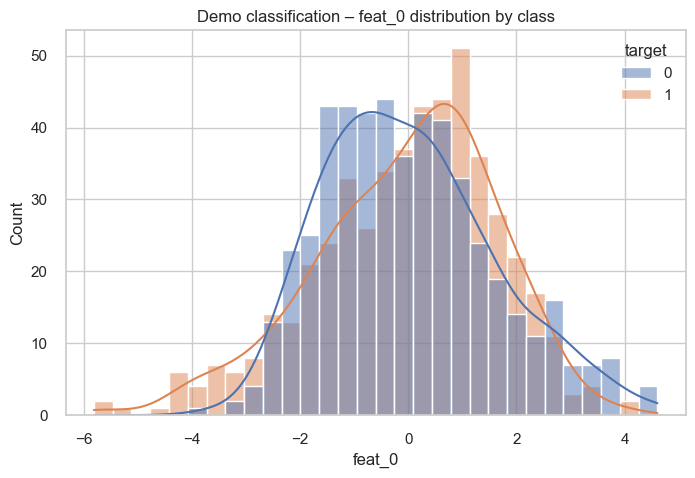

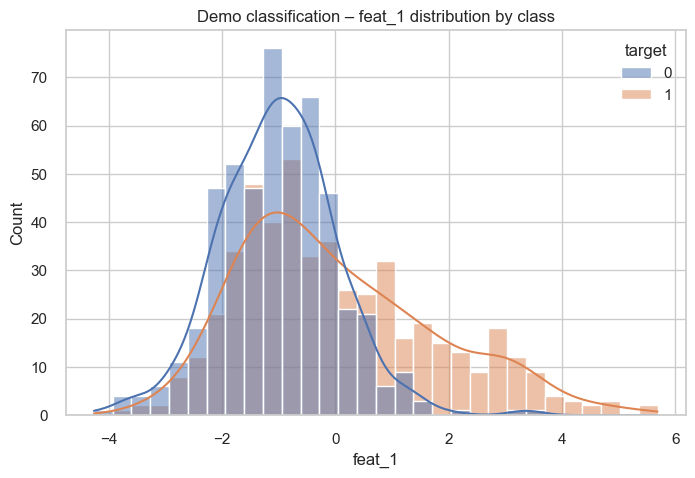

In [5]:
# Histograms for a few classification features
sns.histplot(data=demo_df_class, x="feat_0", hue="target", kde=True, bins=30)
plt.title("Demo classification – feat_0 distribution by class")
plt.show()

sns.histplot(data=demo_df_class, x="feat_1", hue="target", kde=True, bins=30)
plt.title("Demo classification – feat_1 distribution by class")
plt.show()

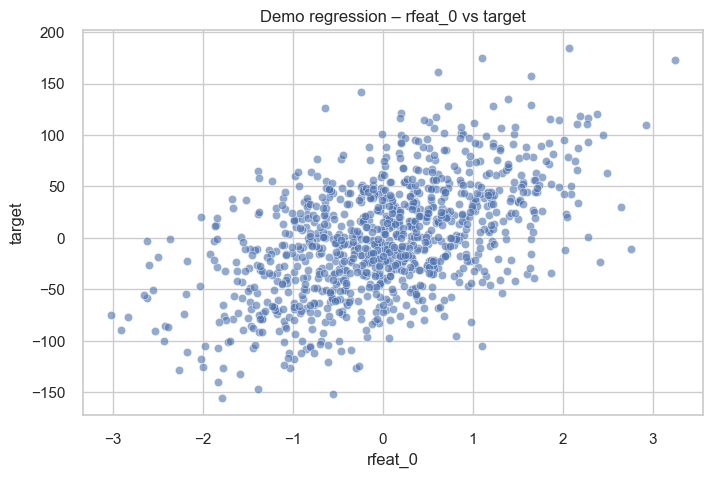

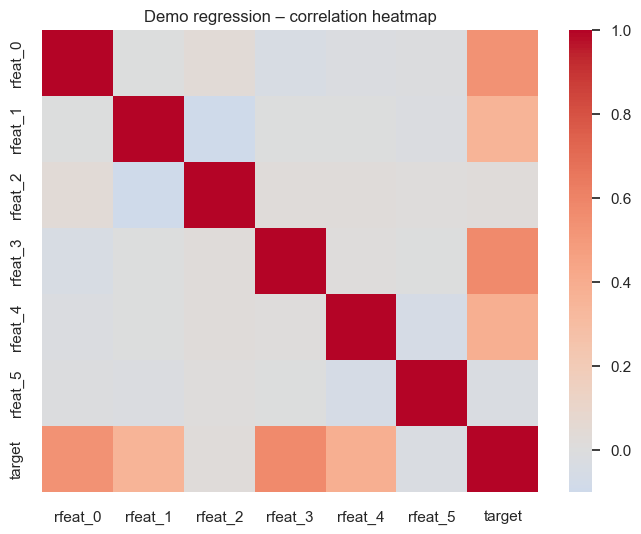

In [6]:
# Scatter plot for regression demo
sns.scatterplot(data=demo_df_reg, x="rfeat_0", y="target", alpha=0.6)
plt.title("Demo regression – rfeat_0 vs target")
plt.show()

# Correlation heatmap for regression features
corr = demo_df_reg.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Demo regression – correlation heatmap")
plt.show()

## 5. Train Simple Models (Classification & Regression)

We now train basic models on the synthetic datasets:

- Classification: `LogisticRegression`, `RandomForestClassifier`
- Regression: `LinearRegression`, `RandomForestRegressor`

In [7]:
# Train/test split for classification demo
(
    demo_Xc_train,
    demo_Xc_test,
    demo_yc_train,
    demo_yc_test,
) = train_test_split(
    demo_df_class.drop(columns=["target"]),
    demo_df_class["target"],
    test_size=0.25,
    random_state=DEMO_RANDOM_STATE,
    stratify=demo_df_class["target"],
)

# Logistic Regression
demo_log_clf = LogisticRegression(max_iter=1000, random_state=DEMO_RANDOM_STATE)
demo_log_clf.fit(demo_Xc_train, demo_yc_train)

# Random Forest Classifier
demo_rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=DEMO_RANDOM_STATE,
)
demo_rf_clf.fit(demo_Xc_train, demo_yc_train)

# Train/test split for regression demo
(
    demo_Xr_train,
    demo_Xr_test,
    demo_yr_train,
    demo_yr_test,
) = train_test_split(
    demo_df_reg.drop(columns=["target"]),
    demo_df_reg["target"],
    test_size=0.25,
    random_state=DEMO_RANDOM_STATE,
)

# Linear Regression
demo_lin_reg = LinearRegression()
demo_lin_reg.fit(demo_Xr_train, demo_yr_train)

# Random Forest Regressor
demo_rf_reg = RandomForestRegressor(
    n_estimators=150,
    random_state=DEMO_RANDOM_STATE,
)
demo_rf_reg.fit(demo_Xr_train, demo_yr_train)

print("Models trained on synthetic data only.")

Models trained on synthetic data only.


In [8]:
# Classification metrics
from collections import OrderedDict

metrics_class = OrderedDict()

for name, model in {
    "LogisticRegression": demo_log_clf,
    "RandomForestClassifier": demo_rf_clf,
}.items():
    demo_yc_pred = model.predict(demo_Xc_test)
    metrics_class[name] = {
        "accuracy": accuracy_score(demo_yc_test, demo_yc_pred),
        "precision": precision_score(demo_yc_test, demo_yc_pred),
        "recall": recall_score(demo_yc_test, demo_yc_pred),
        "f1": f1_score(demo_yc_test, demo_yc_pred),
        "confusion_matrix": confusion_matrix(demo_yc_test, demo_yc_pred),
    }

metrics_class

OrderedDict([('LogisticRegression',
              {'accuracy': 0.812,
               'precision': 0.8235294117647058,
               'recall': 0.7903225806451613,
               'f1': 0.8065843621399177,
               'confusion_matrix': array([[105,  21],
                      [ 26,  98]])}),
             ('RandomForestClassifier',
              {'accuracy': 0.928,
               'precision': 0.9140625,
               'recall': 0.9435483870967742,
               'f1': 0.9285714285714286,
               'confusion_matrix': array([[115,  11],
                      [  7, 117]])})])

In [ ]:
# Regression metrics
metrics_reg = OrderedDict()

for name, model in {
    "LinearRegression": demo_lin_reg,
    "RandomForestRegressor": demo_rf_reg,
}.items():
    demo_yr_pred = model.predict(demo_Xr_test)
    mse = mean_squared_error(demo_yr_test, demo_yr_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(demo_yr_test, demo_yr_pred)
    r2 = r2_score(demo_yr_test, demo_yr_pred)

    metrics_reg[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }

metrics_reg

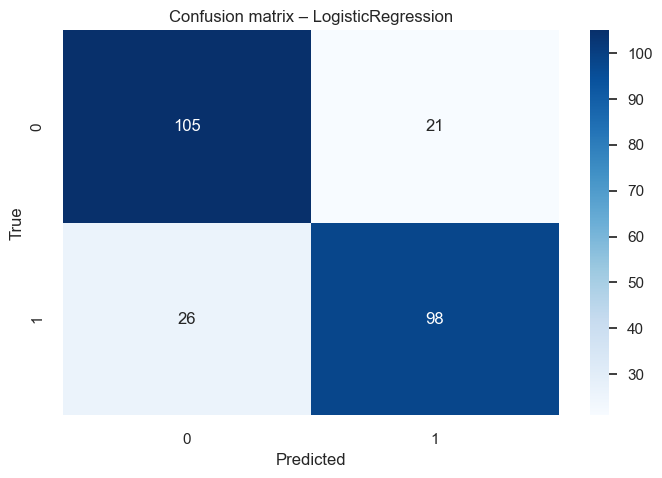

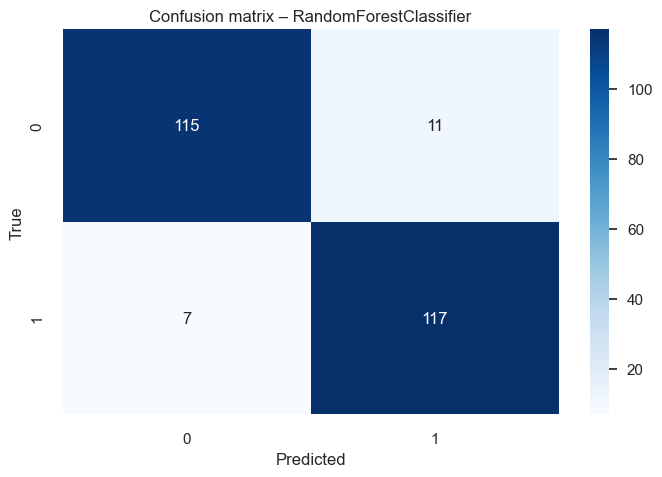

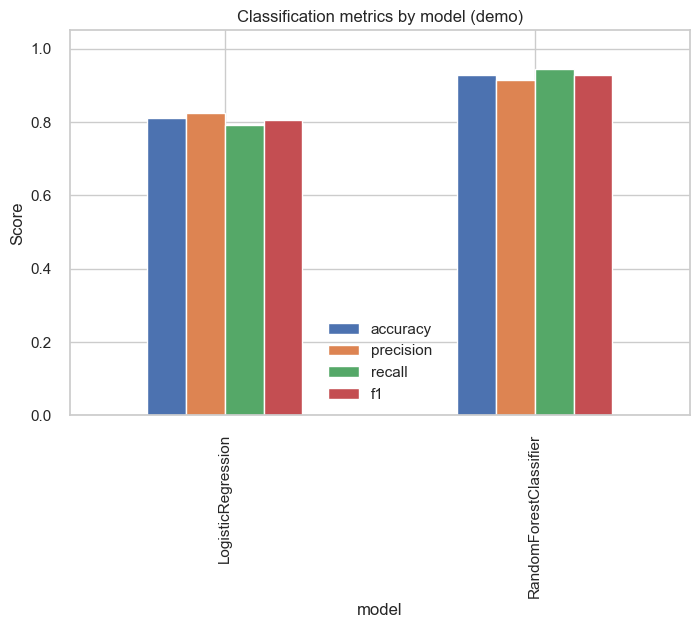

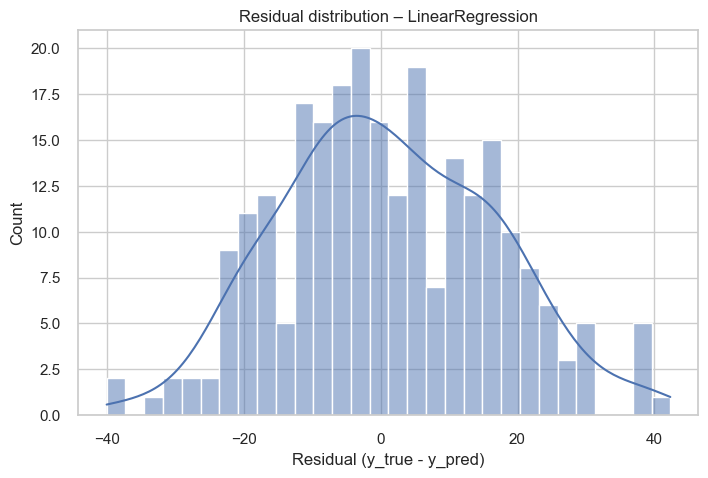

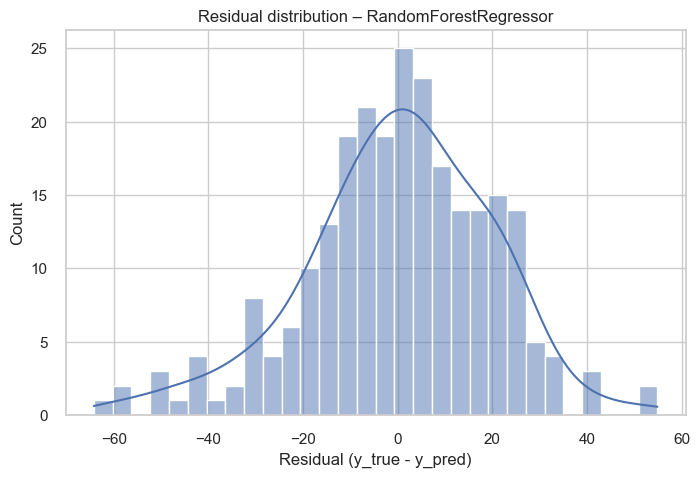

In [9]:
# Confusion matrices
for name, stats in metrics_class.items():
    cm = stats["confusion_matrix"]
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Bar chart of classification metrics
class_rows = []
for name, stats in metrics_class.items():
    row = {"model": name}
    for m in ["accuracy", "precision", "recall", "f1"]:
        row[m] = stats[m]
    class_rows.append(row)

demo_df_class_metrics = pd.DataFrame(class_rows)

demo_df_class_metrics.set_index("model")[
    ["accuracy", "precision", "recall", "f1"]
].plot(kind="bar")
plt.title("Classification metrics by model (demo)")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.show()

# Regression residual plots
for name, model in {
    "LinearRegression": demo_lin_reg,
    "RandomForestRegressor": demo_rf_reg,
}.items():
    demo_yr_pred = model.predict(demo_Xr_test)
    residuals = demo_yr_test - demo_yr_pred

    plt.figure()
    sns.histplot(residuals, kde=True, bins=30)
    plt.title(f"Residual distribution – {name}")
    plt.xlabel("Residual (y_true - y_pred)")
    plt.show()

In [10]:
import os

# Directory dedicated to demo visualizations only
demo_artifacts_dir = os.path.join("artifacts", "demo_viz")
os.makedirs(demo_artifacts_dir, exist_ok=True)

# Example: save a couple of representative figures

# 1) Save a confusion matrix for RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

demo_yc_pred_rf = demo_rf_clf.predict(demo_Xc_test)
cm_rf = confusion_matrix(demo_yc_test, demo_yc_pred_rf)

fig_cm, ax_cm = plt.subplots()
ConfusionMatrixDisplay(cm_rf).plot(ax=ax_cm)
ax_cm.set_title("Confusion matrix – RandomForestClassifier (demo)")
cm_path = os.path.join(demo_artifacts_dir, "confusion_matrix_rf_demo.png")
fig_cm.savefig(cm_path, bbox_inches="tight")
plt.close(fig_cm)

# 2) Save regression residual plot for RandomForestRegressor
demo_yr_pred_rf = demo_rf_reg.predict(demo_Xr_test)
residuals_rf = demo_yr_test - demo_yr_pred_rf

fig_res, ax_res = plt.subplots()
sns.histplot(residuals_rf, kde=True, bins=30, ax=ax_res)
ax_res.set_title("Residual distribution – RandomForestRegressor (demo)")
ax_res.set_xlabel("Residual (y_true - y_pred)")
res_path = os.path.join(demo_artifacts_dir, "residuals_rf_demo.png")
fig_res.savefig(res_path, bbox_inches="tight")
plt.close(fig_res)

print("Saved demo figures to:", demo_artifacts_dir)

Saved demo figures to: artifacts\demo_viz
